In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer         # sklearn에서 제공하는 유방암 예제 데이터 불러오는 함수

from sklearn.model_selection import train_test_split    # 데이터를 학습용/평가용으로 나누는 함수

from sklearn.metrics import accuracy_score              #모델 성능 평가할 때 사용할 지표 함수들
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier                       # 분류 모델 XGBoost

plt.rcParams["axes.unicode_minus"] = False              # 한글 폰트 환경에서 음수 표시가 네모로 깨지는 것 방지

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


In [2]:
data = load_breast_cancer()

feature_names = list(data.feature_names)

print("feature 개수:", len(feature_names))
print("앞쪽 5개 feature 이름:", feature_names[:5])

feature 개수: 30
앞쪽 5개 feature 이름: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]


In [3]:
X = pd.DataFrame(data.data, columns=feature_names)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
y_original = pd.Series(data.target, name="target_original")

y = 1 - y_original

y.name = "target"

compare_label = pd.DataFrame({
    "target_original (0=악성, 1=양성)": y_original,
    "target (0=양성, 1=악성)": y
})
compare_label.head()

,"target_original (0=악성, 1=양성)","target (0=양성, 1=악성)"
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [5]:
label_to_name = {0: "benign", 1: "malignant"}

target_name = y.map(label_to_name)
target_name.name = "target_name"

target_name.value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [6]:
target_name

0      malignant
1      malignant
2      malignant
3      malignant
4      malignant
         ...    
564    malignant
565    malignant
566    malignant
567    malignant
568       benign
Name: target_name, Length: 569, dtype: str

In [7]:
df = X.copy()

df["target"] = y.values
df["target_name"] = target_name.values

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,malignant


In [8]:
selected_features = [
    "mean radius",
    "mean perimeter",
    "mean area",
    "mean concave points",
    "worst radius",
    "worst perimeter",
    "worst area",
    "worst concave points"
]

print("선택한 feature 개수:", len(selected_features))
print("모두 데이터에 존재?:", all(f in feature_names for f in selected_features))

선택한 feature 개수: 8
모두 데이터에 존재?: True


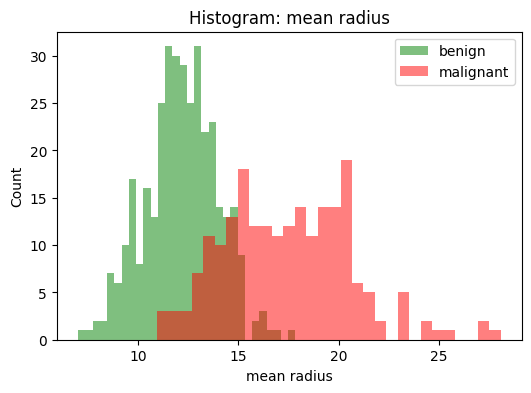

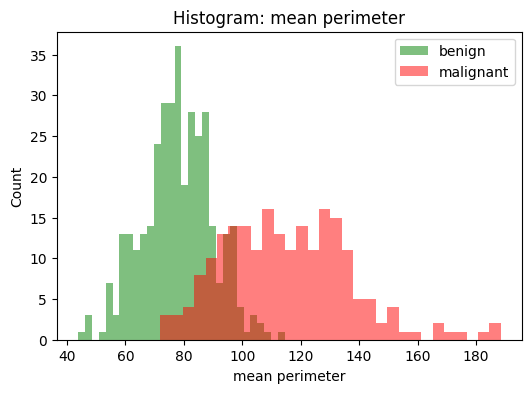

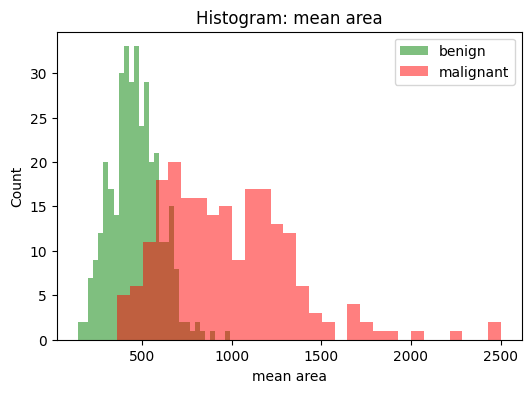

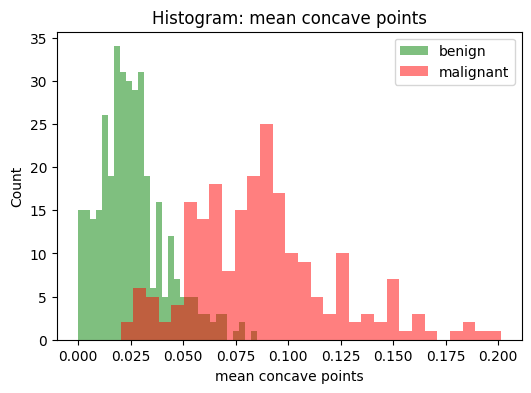

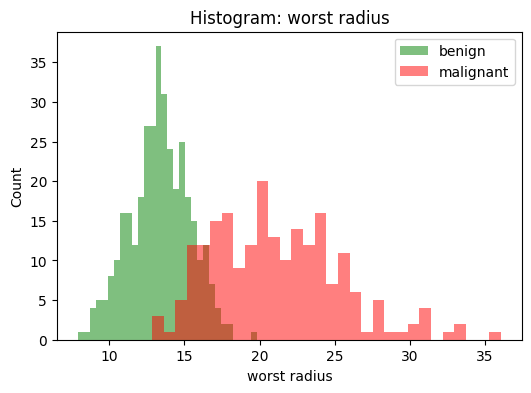

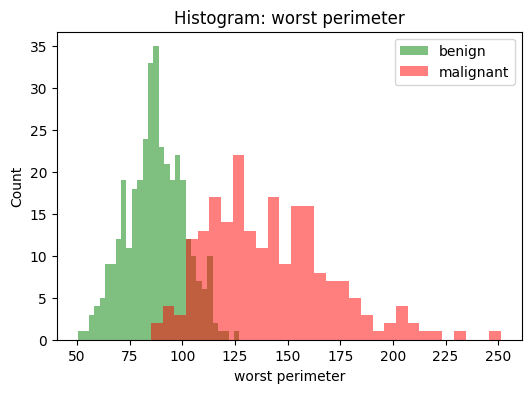

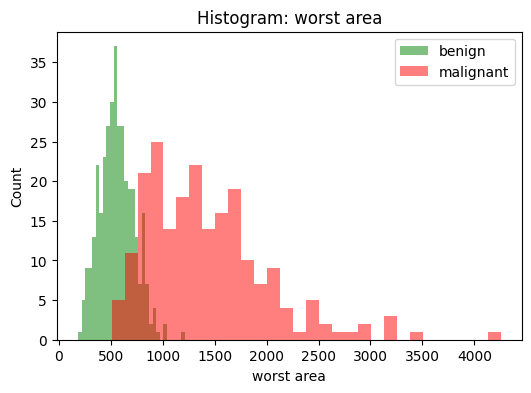

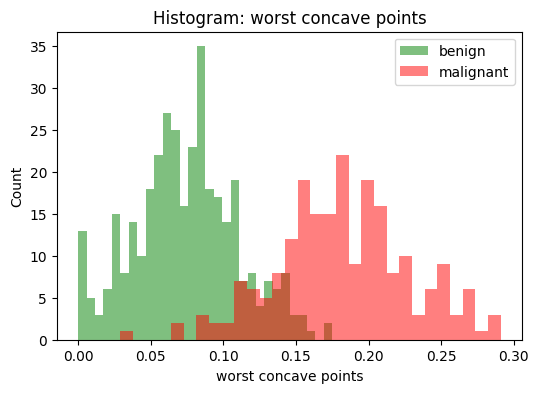

In [9]:
# 그래프에서 양성/악성 데이터를 따로 떼어 두면 반복해서 쓰기 편함
benign_df = df[df["target_name"] == "benign"]
malignant_df = df[df["target_name"] == "malignant"]

for feature in selected_features:
    plt.figure(figsize=(6, 4))

    plt.hist(benign_df[feature], bins=30, alpha=0.5, label="benign", color="green")

    plt.hist(malignant_df[feature], bins=30, alpha=0.5, label="malignant", color="red")

    plt.title("Histogram: " +feature)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()    # benign/malignant 구분 범례 표시
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_2244\3808932124.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


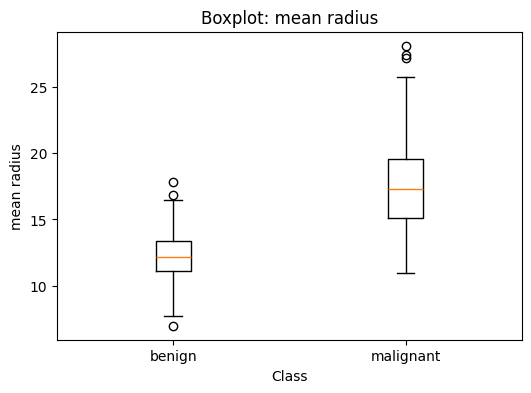

C:\Users\user\AppData\Local\Temp\ipykernel_2244\3808932124.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


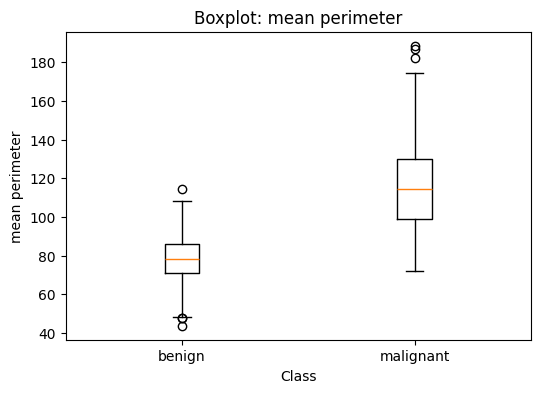

C:\Users\user\AppData\Local\Temp\ipykernel_2244\3808932124.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


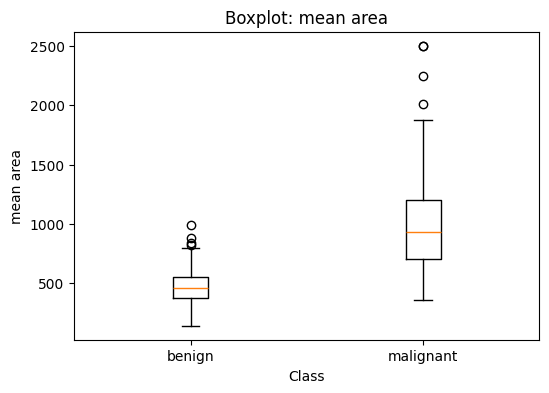

C:\Users\user\AppData\Local\Temp\ipykernel_2244\3808932124.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


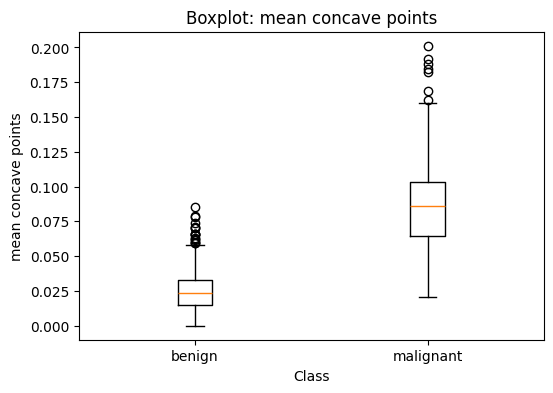

C:\Users\user\AppData\Local\Temp\ipykernel_2244\3808932124.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


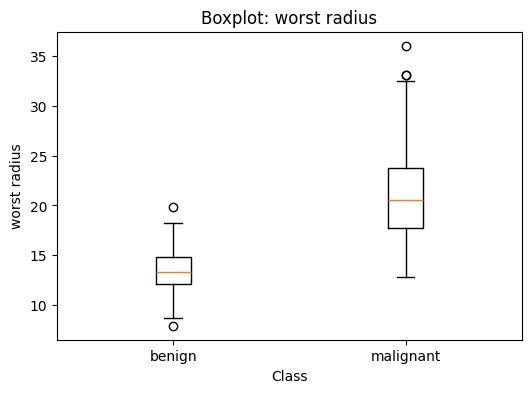

C:\Users\user\AppData\Local\Temp\ipykernel_2244\3808932124.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


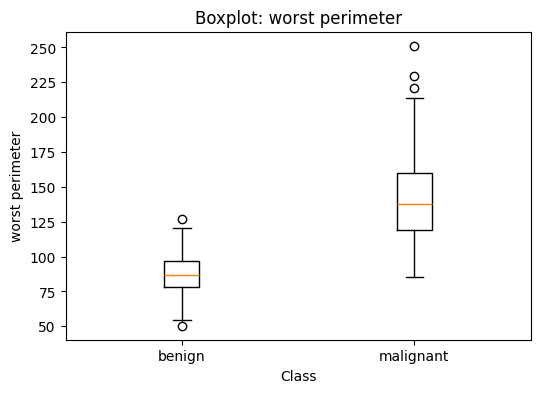

C:\Users\user\AppData\Local\Temp\ipykernel_2244\3808932124.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


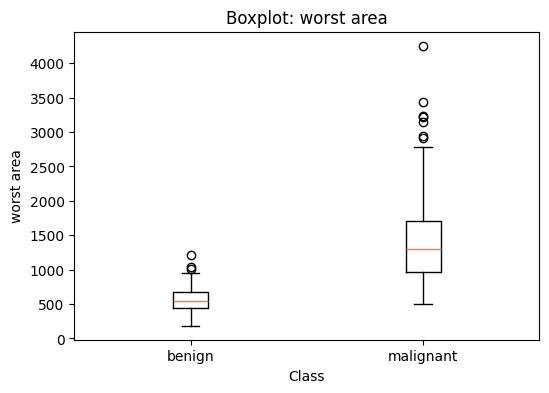

C:\Users\user\AppData\Local\Temp\ipykernel_2244\3808932124.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


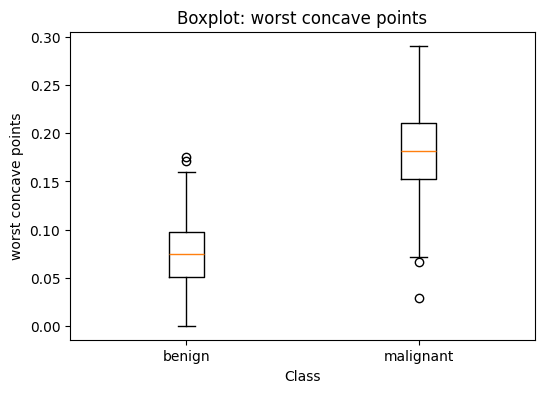

In [10]:
for feature in selected_features:
    plt.figure(figsize=(6, 4))

    data_for_box = [benign_df[feature], malignant_df[feature]]

    plt.boxplot(data_for_box, labels=["benign", "malignant"])

    plt.title("Boxplot: " + feature)
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.show()

In [11]:
target_corr = df[feature_names+["target"]].corr()["target"].drop("target")
target_corr.sort_values(ascending=False).head(15)

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
mean compactness        0.596534
worst compactness       0.590998
radius error            0.567134
perimeter error         0.556141
area error              0.548236
Name: target, dtype: float64

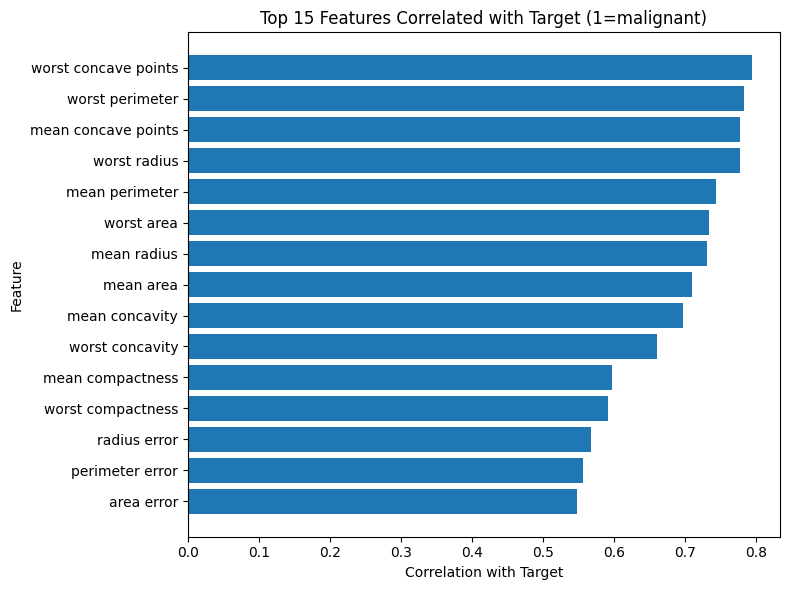

In [12]:
top15_corr = target_corr.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))

plt.barh(top15_corr.index, top15_corr.values)

plt.gca().invert_yaxis()

plt.title("Top 15 Features Correlated with Target (1=malignant)")
plt.xlabel("Correlation with Target")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

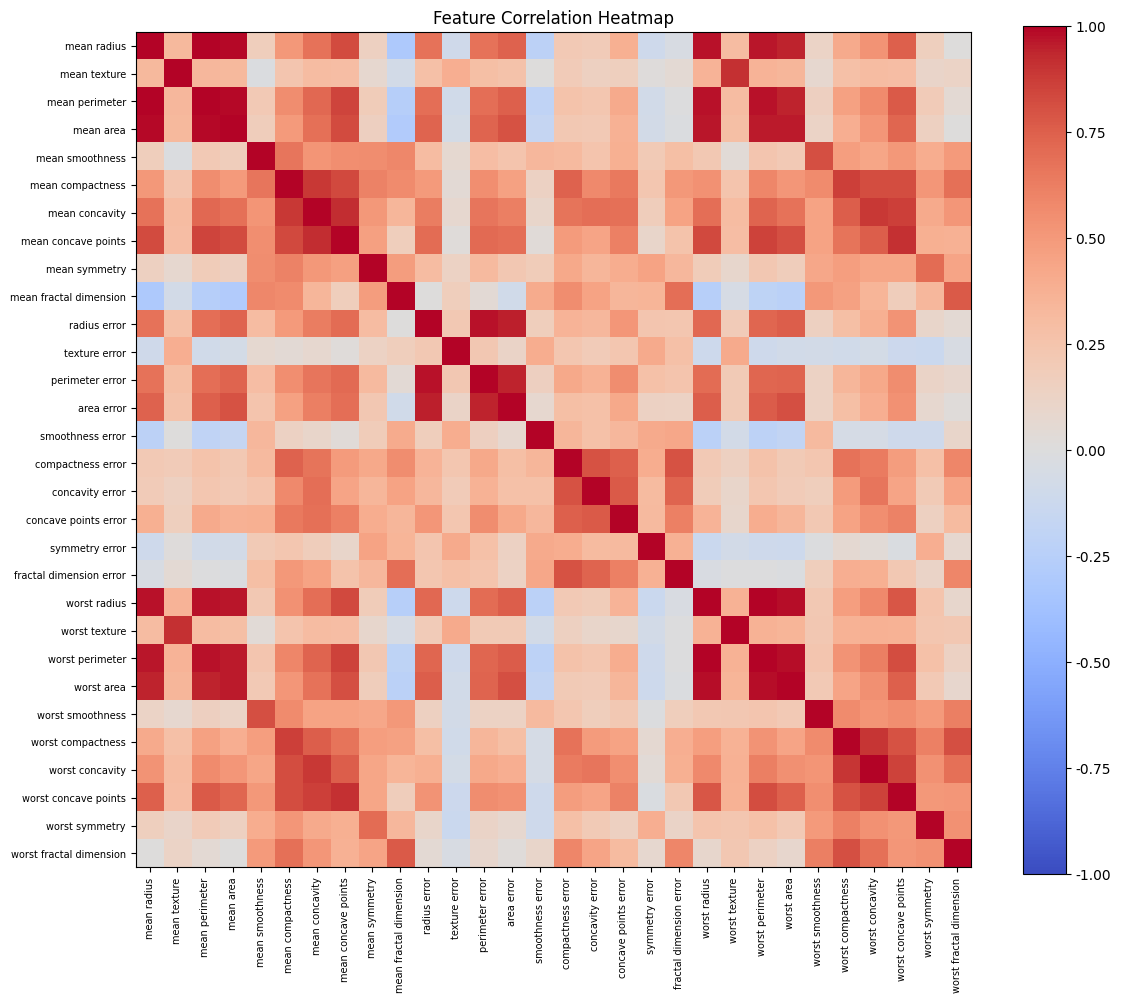

In [13]:
corr_matrix = df[feature_names].corr()

plt.figure(figsize=(12, 10))

image = plt.imshow(corr_matrix.values, cmap="coolwarm", vmin= -1, vmax = 1)

plt.colorbar(image)

plt.xticks(range(len(feature_names)), feature_names, rotation = 90, fontsize = 7)
plt.yticks(range(len(feature_names)), feature_names, fontsize = 7)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("학습용 입력 크기:", X_train.shape)
print("평가용 입력 크기:", X_test.shape)

print("\n학습용 악성 비율:", round(y_train.mean(), 3))
print("평가용 악성 비율:", round(y_test.mean(), 3))

학습용 입력 크기: (455, 30)
평가용 입력 크기: (114, 30)

학습용 악성 비율: 0.374
평가용 악성 비율: 0.368


In [15]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

print("모델 생성 완료:", type(model).__name__)

모델 생성 완료: XGBClassifier


In [16]:
model.fit(X_train, y_train)

print("모델 학습 완료")

모델 학습 완료


In [17]:
y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy(정확도):", round(accuracy, 4))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", round(roc_auc, 4))

Accuracy(정확도): 0.9649
ROC-AUC: 0.9967


In [18]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["benign", "malignant"]
)

print(report)

              precision    recall  f1-score   support

      benign       0.95      1.00      0.97        72
   malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [19]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72  0]
 [ 4 38]]


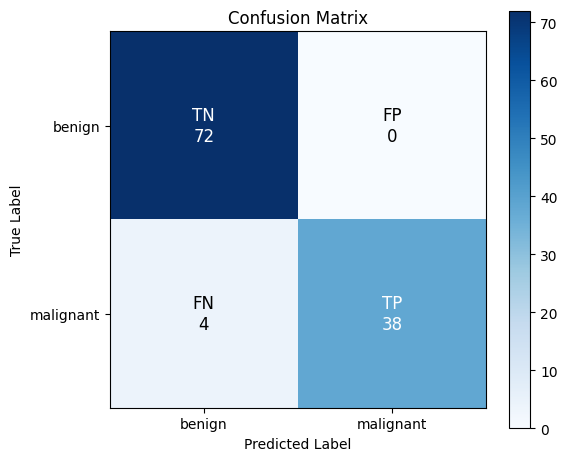

In [20]:
cell_labels = [["TN", "FP"],
                ["FN", "TP"]]

plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0, 1], ["benign", "malignant"])
plt.yticks([0, 1], ["benign", "malignant"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

for row in range(2):
    for col in range(2):
        text = cell_labels[row][col] + "\n" + str(cm[row, col])
        color = "white" if cm[row, col] > cm.max() / 2 else "black"
        plt.text(col, row, text, ha="center", va="center", color=color, fontsize=12)

plt.tight_layout()
plt.show()

In [21]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
22,worst perimeter,0.325854
7,mean concave points,0.168878
20,worst radius,0.132685
27,worst concave points,0.107395
26,worst concavity,0.034402
14,smoothness error,0.024641
21,worst texture,0.021746
3,mean area,0.021613
1,mean texture,0.020148
10,radius error,0.015719


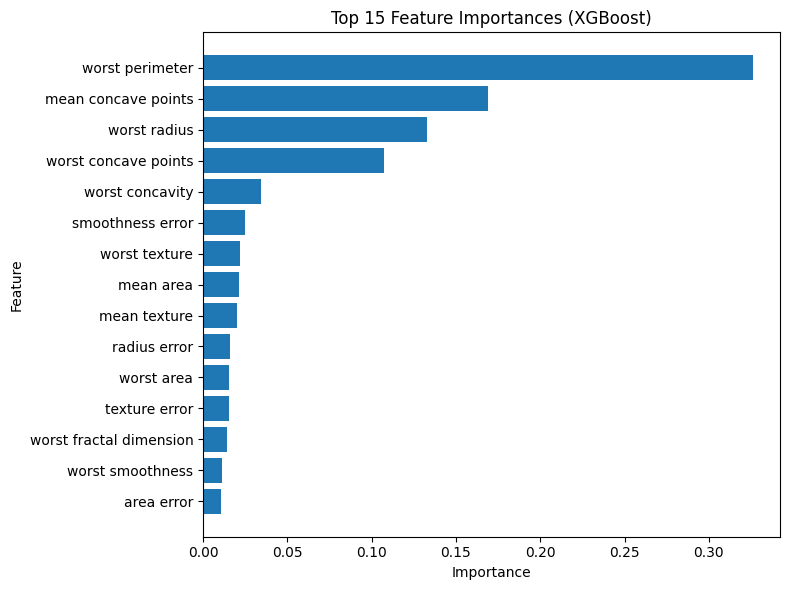

In [22]:
top15_importance = importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top15_importance["feature"], top15_importance["importance"])

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()